In [1]:
import numpy as np
from astropy import units as u
from astropy.table import Table
from astropy.time import Time
from WDBinary import WDBinary
from WDBinary3 import WDBinary3

from scipy import integrate
from astropy.constants import G, c, M_sun

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

In [2]:
mass_wd=0.5,   
r_wd=0.012 * u.Rsun
l_wd=1e-5
mass_star=1.0 
r_star=1.0 * u.Rsun
l_star=1.0
ecc=0.0
a = 0.48 * u.au
d = 1000.0 * u.pc
inc_deg=90 * u.deg
omega_deg=90.0 * u.deg
limb_darkening=[0.4, 0.2]
cycle = 1
N=200000

binary = WDBinary3(
    mass_wd, r_wd, l_wd,
    mass_star, r_star, l_star,
    ecc, a, d, omega=omega_deg, cycles=1.0,
    inc=inc_deg,
    limb_darkening=[0.3, 0.2],
    N=N
)

/Users/wanglm/anaconda3/envs/pygyre_env/lib/python3.11/site-packages/astropy/units/quantity.py:671: RuntimeWarning: invalid value encountered in sqrt
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


In [3]:
binary.eclipse_duration()
(binary.tra_tot / u.rad).to(u.hr)

<Quantity [7.4288031] h>

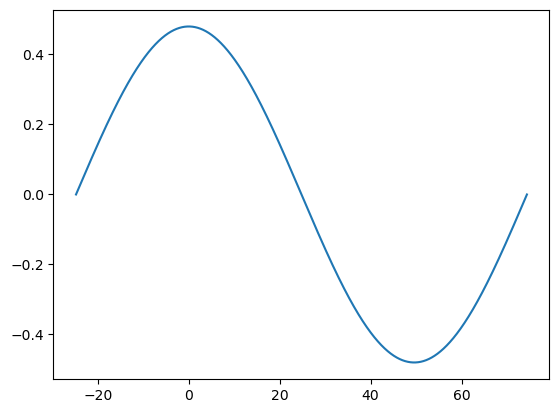

In [4]:
plt.plot(binary.t, binary.Z)

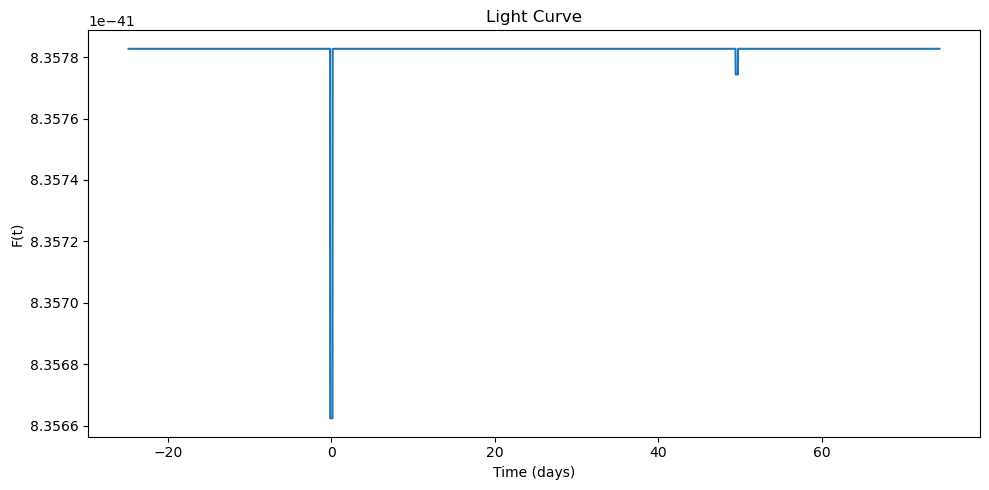

In [20]:
# Plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot((binary.t).to(u.day).value, binary.geo_flux)
ax.set_xlabel("Time (days)")
ax.set_ylabel("F(t)")
ax.set_title("Light Curve")
plt.tight_layout()
plt.show()

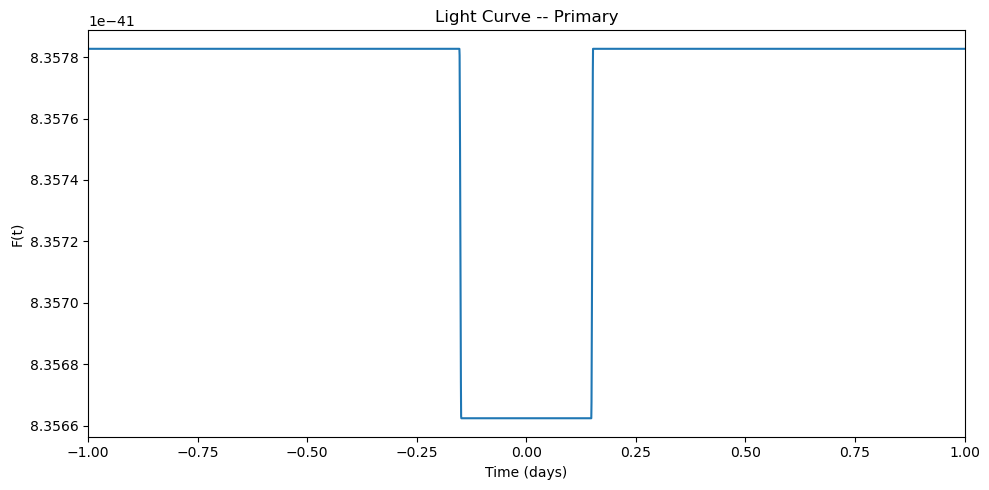

In [21]:
# Plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot((binary.t).to(u.day).value, binary.geo_flux)
ax.set_xlabel("Time (days)")
ax.set_ylabel("F(t)")
ax.set_title("Light Curve -- Primary")
ax.set_xlim(-1, 1)
plt.tight_layout()
plt.show()

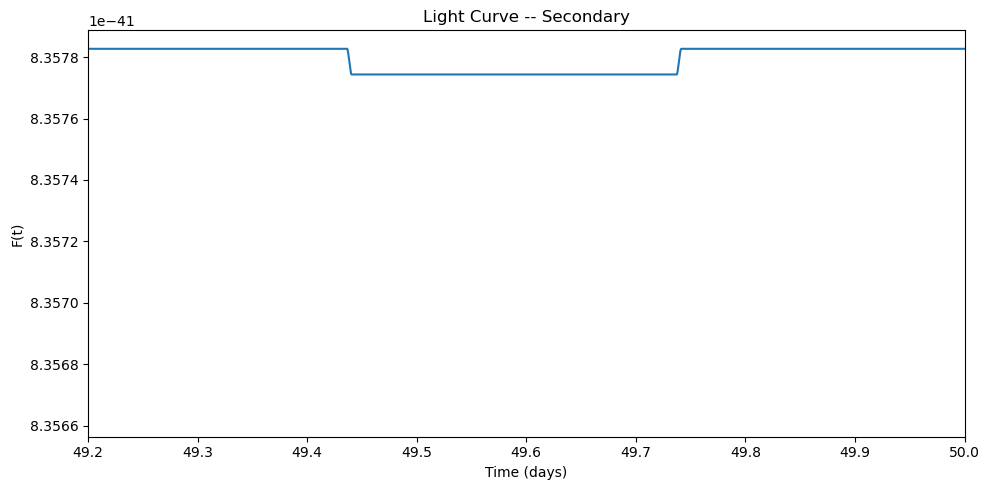

In [22]:
# Plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot((binary.t).to(u.day).value, binary.geo_flux)
ax.set_xlabel("Time (days)")
ax.set_ylabel("F(t)")
ax.set_title("Light Curve -- Secondary")
ax.set_xlim(49.2, 50)
plt.tight_layout()
plt.show()

test case to check r_sky written by Claude

Array starts inside eclipse: False
Expected eclipses (2 per orbit x 1.0 cycles): 2.0
Found complete eclipses: 2

  Eclipse  1: duration = 7.2242 hr
  Eclipse  2: duration = 7.2242 hr

Max spread in durations: 0.0000 hr
Timestep:                0.0119 hr
Spread within 2 timesteps (sampling tolerance): True

All assertions passed — r_sky dip durations are uniform.


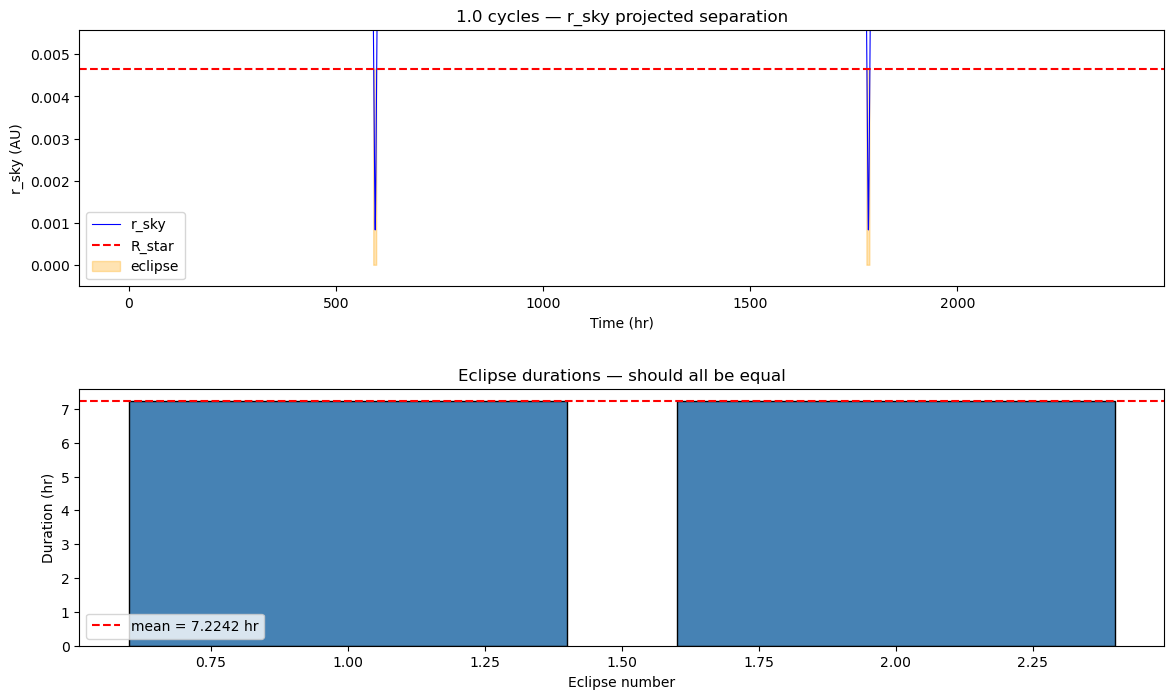

In [6]:
# ── Test: r_sky dip durations are uniform across all cycles ──────────────────

mass_wd   = 0.5
r_wd      = 0.012 * u.Rsun
l_wd      = 1e-5
mass_star = 1.0
r_star    = 1.0 * u.Rsun
l_star    = 1.0
ecc       = 0.0
a         = 0.48 * u.au
d         = 1000.0 * u.pc
inc_deg   = 89.9 * u.deg
omega_deg = 90.0 * u.deg
cycles    = 1.0

binary = WDBinary3(
    mass_wd, r_wd, l_wd,
    mass_star, r_star, l_star,
    ecc, a, d,
    omega=omega_deg,
    inc=inc_deg,
    cycles=cycles,
    limb_darkening=[0.3, 0.2],
    N=N,
)

r_sky_au   = binary.r_sky.to(u.au)
R_star_au  = binary.R_star.to(u.au)
eclipse    = r_sky_au.value < R_star_au.value

# ── Check boundary condition ──────────────────────────────────────────────────
print(f"Array starts inside eclipse: {eclipse[0]}")
if eclipse[0]:
    print("WARNING: time array starts inside an eclipse — first/last durations will")
    print("appear short due to boundary truncation, not a real physical difference.")
    print("Fix: offset t by -P/4 in WDBinary3.__init__ so no conjunction falls at t=0.\n")

# ── Find eclipse regions ──────────────────────────────────────────────────────
changes = np.diff(eclipse.astype(int))
starts  = np.where(changes  > 0)[0]
ends    = np.where(changes  < 0)[0]

print(f"Expected eclipses (2 per orbit x {cycles} cycles): {2 * cycles}")
print(f"Found complete eclipses: {len(starts)}\n")

durations = [(binary.t[ends[i]] - binary.t[starts[i]]).to(u.hr).value
             for i in range(len(starts))]

for i, dur in enumerate(durations):
    print(f"  Eclipse {i+1:2d}: duration = {dur:.4f} hr")

max_spread = np.max(durations) - np.min(durations)
timestep   = (binary.t[1] - binary.t[0]).to(u.hr).value
print(f"\nMax spread in durations: {max_spread:.4f} hr")
print(f"Timestep:                {timestep:.4f} hr")
print(f"Spread within 2 timesteps (sampling tolerance): {max_spread < 2 * timestep}")

# ── Assert ────────────────────────────────────────────────────────────────────
assert not eclipse[0], \
    "Time array starts inside an eclipse — boundary artifact will corrupt duration test."
assert len(starts) == 2 * cycles, \
    f"Expected {2 * cycles} eclipses, got {len(starts)}."
assert max_spread < 2 * timestep, \
    f"Eclipse durations not uniform: spread = {max_spread:.4f} hr > 2 timesteps = {2*timestep:.4f} hr."

print("\nAll assertions passed — r_sky dip durations are uniform.")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(14, 8))
gs  = GridSpec(2, 1, figure=fig, hspace=0.4)

t_display = (binary.t - binary.t[0]).to(u.hr).value

ax0 = fig.add_subplot(gs[0])
ax0.plot(t_display, r_sky_au.value, 'b-', lw=0.8, label='r_sky')
ax0.axhline(R_star_au.value, color='r', ls='--', lw=1.5, label='R_star')
ax0.fill_between(t_display, 0, R_star_au.value,
                 where=eclipse, alpha=0.3, color='orange', label='eclipse')
ax0.set_xlabel('Time (hr)')
ax0.set_ylabel('r_sky (AU)')
ax0.set_title(f'{cycles} cycles — r_sky projected separation')
ax0.set_ylim(-0.0005, R_star_au.value * 1.2)
ax0.legend()

ax1 = fig.add_subplot(gs[1])
ax1.bar(range(1, len(durations) + 1), durations, color='steelblue', edgecolor='k')
ax1.axhline(np.mean(durations), color='r', ls='--', label=f'mean = {np.mean(durations):.4f} hr')
ax1.set_xlabel('Eclipse number')
ax1.set_ylabel('Duration (hr)')
ax1.set_title('Eclipse durations — should all be equal')
ax1.legend()

plt.show()